In [1]:
import numpy as np
import cv2

# 1. Create Dummy Dataset (images + bounding boxes)
# Each label: [x_center, y_center, width, height, class]

IMAGE_SIZE = 128
NUM_CLASSES = 1

def create_dataset(samples=200):
    images = []
    labels = []

    for _ in range(samples):

        img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)

        x = np.random.randint(20, 90)
        y = np.random.randint(20, 90)
        w = np.random.randint(20, 40)
        h = np.random.randint(20, 40)

        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 255, 255), -1)

        x_center = (x + w/2) / IMAGE_SIZE
        y_center = (y + h/2) / IMAGE_SIZE
        w = w / IMAGE_SIZE
        h = h / IMAGE_SIZE

        images.append(img / 255.0)
        labels.append([x_center, y_center, w, h, 1])

    return np.array(images), np.array(labels)

X, y = create_dataset()

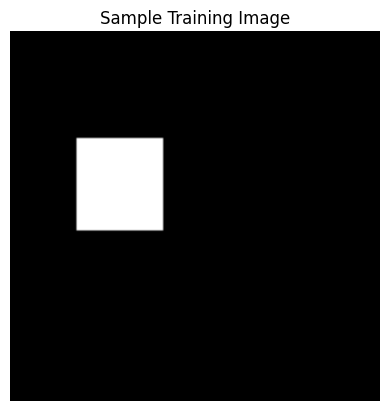

In [2]:
import matplotlib.pyplot as plt

plt.imshow(X[0])
plt.title("Sample Training Image")
plt.axis("off")
plt.show()

In [3]:
# ------------------------------------
# 2. Train / Test Split
# ------------------------------------

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [4]:
import tensorflow as tf

# ------------------------------------
# 3. Build a YOLO-like CNN Model
# ------------------------------------

model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    # Output: bounding box + class
    tf.keras.layers.Dense(5, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,989 (6.22 MB)

 Trainable params: 1,629,989 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ------------------------------------
# 4. Train Model
# ------------------------------------

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=8
)

# ------------------------------------
# 5. Evaluate Model
# ------------------------------------

loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0189 - val_loss: 0.0049
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0036 - val_loss: 0.0041
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022 - val_loss: 0.0027
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.4791e-04 - val_loss: 0.0016
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.6311e-04 - val_loss: 0.0013
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.4207e-04 - val_loss: 0.0014
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.8338e-04 - val_loss: 0.0014
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.8313e-04 - val_loss: 0.0014
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2139e-04 - val_loss: 0.0014
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - loss: 0.0015
Test Loss: 0.001461008214391768


In [6]:
# ------------------------------------
# 6. IoU (Intersection over Union)
# ------------------------------------

def IoU(box1, box2):

    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    x1_min = x1 - w1/2
    x1_max = x1 + w1/2
    y1_min = y1 - h1/2
    y1_max = y1 + h1/2

    x2_min = x2 - w2/2
    x2_max = x2 + w2/2
    y2_min = y2 - h2/2
    y2_max = y2 + h2/2

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)

    area1 = w1 * h1
    area2 = w2 * h2

    union = area1 + area2 - inter_area

    return inter_area / union

In [7]:
# ------------------------------------
# 7. Test Predictions
# ------------------------------------

preds = model.predict(X_test[:5])

for i in range(5):

    pred_box = preds[i][:4]
    true_box = y_test[i][:4]

    iou = IoU(pred_box, true_box)

    print("\nExample", i+1)
    print("True Box:", true_box)
    print("Pred Box:", pred_box)
    print("IoU:", iou)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step

Example 1
True Box: [0.51171875 0.82421875 0.2265625  0.2890625 ]
Pred Box: [0.5277265  0.7859396  0.26772875 0.20755866]
IoU: 0.6351713728379231

Example 2
True Box: [0.78125  0.671875 0.28125  0.296875]
Pred Box: [0.76873183 0.6612613  0.28671265 0.28247818]
IoU: 0.8537650044641556

Example 3
True Box: [0.6640625  0.48828125 0.21875    0.1640625 ]
Pred Box: [0.66920996 0.49025884 0.1938182  0.2473169 ]
IoU: 0.6112132738777359

Example 4
True Box: [0.8046875 0.3125    0.234375  0.28125  ]
Pred Box: [0.78440183 0.3281144  0.26461518 0.26832423]
IoU: 0.7663576937382821

Example 5
True Box: [0.5234375  0.62109375 0.265625   0.2734375 ]
Pred Box: [0.5346917  0.64483905 0.1864134  0.21975955]
IoU: 0.5640245519326657
